In [44]:
%pip install scikit-learn pandas sqlalchemy joblib xgboost python-dotenv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from dotenv import load_dotenv
import os

load_dotenv()

DB_HOST = os.getenv("DB_HOST")

print(DB_HOST)

localhost


In [6]:
from sqlalchemy import create_engine
import pandas as pd
import os

DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")

engine = create_engine(
    f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

print("Database connected")

Database connected


In [8]:

df = pd.read_csv(r"D:\Blinkit_final_project\data\blinkit_orders.csv")

df.head()

,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id
0,1961864118,30065862,2024-07-17 8:34:01,2024-07-17 8:52:01,2024-07-17 8:47:01,On Time,3197.07,Cash,63230,4771
1,1549769649,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,Cash,14983,7534
2,9185164487,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,UPI,39859,9886
3,9644738826,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,Card,61497,7917
4,5427684290,83298567,2023-11-20 5:00:39,2023-11-20 5:17:39,2023-11-20 5:18:39,On Time,2526.68,Cash,84315,2741


In [9]:

df = pd.read_csv(r"D:\Blinkit_final_project\data\blinkit_customer_feedback.csv")

df.head()

,feedback_id,order_id,customer_id,rating,feedback_text,feedback_category,sentiment,feedback_date
0,2234710,1961864118,30065862,4,"It was okay, nothing special.",Delivery,Neutral,2024-07-17
1,5450964,1549769649,9573071,3,The order was incorrect.,App Experience,Negative,2024-05-28
2,482108,9185164487,45477575,3,"It was okay, nothing special.",App Experience,Neutral,2024-09-23
3,4823104,9644738826,88067569,4,The product met my expectations.,App Experience,Neutral,2023-11-24
4,3537464,5427684290,83298567,3,Product was damaged during delivery.,Delivery,Negative,2023-11-20


In [10]:

df = pd.read_csv(r"D:\Blinkit_final_project\data\blinkit_customers.csv")

df.head()

,customer_id,customer_name,email,phone,address,area,pincode,registration_date,customer_segment,total_orders,avg_order_value
0,97475543,Niharika Nagi,ektataneja@example.org,912987579691,"23, Nayar Path, Bihar Sharif-154625",Udupi,321865,2023-05-13,Premium,13,451.92
1,22077605,Megha Sachar,vedant45@example.com,915123179717,"51/302, Buch Chowk\nSrinagar-570271",Aligarh,149394,2024-06-18,Inactive,4,825.48
2,47822591,Hema Bahri,samiazaan@example.com,910034076149,"941\nAnne Street, Darbhanga 186125",Begusarai,621411,2024-09-25,Regular,17,1969.81
3,79726146,Zaitra Vig,ishanvi87@example.org,916264232390,"43/94, Ghosh, Alappuzha 635655",Kozhikode,826054,2023-10-04,New,4,220.09
4,57102800,Januja Verma,atideshpande@example.org,917293526596,"06\nOm, Ambarnath 477463",Ichalkaranji,730539,2024-03-22,Inactive,14,578.14


In [13]:

df = pd.read_csv(r"D:\Blinkit_final_project\data\blinkit_products.csv")

df.head()

,product_id,product_name,category,brand,price,mrp,margin_percentage,shelf_life_days,min_stock_level,max_stock_level
0,153019,Onions,Fruits & Vegetables,Aurora LLC,947.95,1263.93,25,3,13,88
1,11422,Potatoes,Fruits & Vegetables,Ramaswamy-Tata,127.16,169.55,25,3,20,65
2,669378,Potatoes,Fruits & Vegetables,Chadha and Sons,212.14,282.85,25,3,23,70
3,848226,Tomatoes,Fruits & Vegetables,Barad and Sons,209.59,279.45,25,3,10,51
4,890623,Onions,Fruits & Vegetables,"Sangha, Nagar and Varty",354.52,472.69,25,3,27,55


In [14]:

df = pd.read_csv(r"D:\Blinkit_final_project\data\blinkit_order_items.csv")

df.head()

,order_id,product_id,quantity,unit_price
0,1961864118,642612,3,517.03
1,1549769649,378676,1,881.42
2,9185164487,741341,2,923.84
3,9644738826,561860,1,874.78
4,5427684290,602241,2,976.55


In [15]:

df = pd.read_csv(r"D:\Blinkit_final_project\data\blinkit_marketing_performance.csv")

df.head()

,campaign_id,campaign_name,date,target_audience,channel,impressions,clicks,conversions,spend,revenue_generated,roas
0,548299,New User Discount,2024-11-05,Premium,App,3130,163,78,1431.85,4777.75,3.60
1,390914,Weekend Special,2024-11-05,Inactive,App,3925,494,45,4506.34,6238.11,2.98
2,834385,Festival Offer,2024-11-05,Inactive,Email,7012,370,78,4524.23,2621.00,2.95
3,241523,Flash Sale,2024-11-05,Inactive,SMS,1115,579,86,3622.79,2955.00,2.84
4,595111,Membership Drive,2024-11-05,New Users,Email,7172,795,54,2888.99,8951.81,2.22


In [23]:
df = pd.read_sql("SELECT * FROM orders_with_customer", engine)

print("orders with customer:", len(df))
df.head()

orders with customer: 5000


,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,area,customer_segment
0,1961864118,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,Allahabad,Regular
1,1549769649,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,Thrissur,New
2,9185164487,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,Vellore,Inactive
3,9644738826,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,Gaya,Premium
4,5427684290,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,Asansol,Premium


In [24]:
print(df.shape)
print(df.columns)

(5000, 9)
Index(['order_id', 'customer_id', 'order_date', 'promised_delivery_time',
       'actual_delivery_time', 'delivery_status', 'order_total', 'area',
       'customer_segment'],
      dtype='str')


## Target Variable: `is_late`

- 0 -- On Time
- 1 -- Delay

delivery_status


In [25]:
df['is_late'] = df['delivery_status'].apply(
    lambda x: 0 if x == 'On Time' else 1
)

df['is_late'].value_counts(normalize=True) * 100

is_late
0    69.4
1    30.6
Name: proportion, dtype: float64

In [ ]:
%pip install matplotlib

C:\Users\TNQ\AppData\Local\Temp\ipykernel_4488\3944669220.py:3: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  df['is_late'].value_counts().plot(


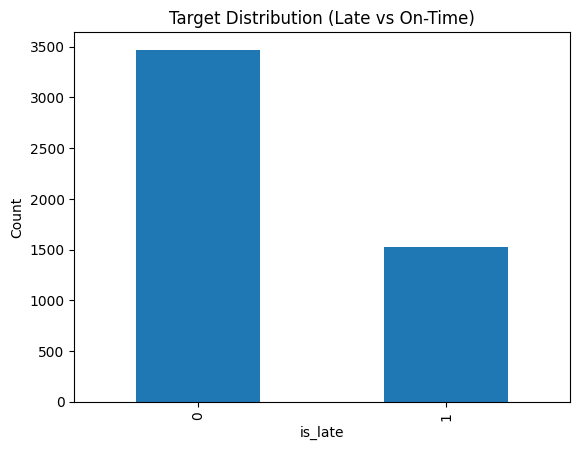

In [28]:
import matplotlib.pyplot as plt

df['is_late'].value_counts().plot(
    kind='bar',
    title='Target Distribution (Late vs On-Time)',
    ylabel='Count'
)
plt.show()


## Feature Engineering

- Order time
- Day of week
- Area
- Historical delay patterns

In [29]:
df['order_date'] = pd.to_datetime(df['order_date'])

df['order_hour'] = df['order_date'].dt.hour
df['day_of_week'] = df['order_date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
df['is_peak_hour'] = df['order_hour'].isin([18, 19, 20, 21]).astype(int)

## Historical Delay Risk Features

These represent **prior operational knowledge** derived from past data:

- Area-level delay rate
- Area + Hour delay rate
- Hour-level delay rate


In [30]:
# ------- area_delay -------- #
area_delay = df.groupby('area')['is_late'].mean().to_dict()
df['area_delay_rate'] = df['area'].map(area_delay)


In [31]:
# ------ area_hour_delay -------- #
area_hour_delay = (
    df.groupby(['area', 'order_hour'])['is_late']
      .mean()
      .to_dict()
)

df['area_hour_delay_rate'] = df.apply(
    lambda r: area_hour_delay.get((r['area'], r['order_hour']), 0),
    axis=1
)

In [32]:
# -------- hour_delay -------- #
hour_delay = df.groupby('order_hour')['is_late'].mean().to_dict()
df['hour_delay_rate'] = df['order_hour'].map(hour_delay)

C:\Users\TNQ\AppData\Local\Temp\ipykernel_4488\477972364.py:1: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  df.groupby('order_hour')['is_late'].mean().plot(


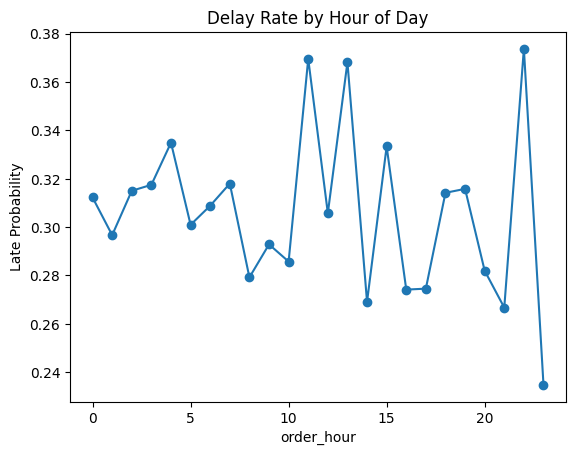

In [33]:
df.groupby('order_hour')['is_late'].mean().plot(
    kind='line',
    marker='o',
    title='Delay Rate by Hour of Day'
)
plt.ylabel('Late Probability')
plt.show()

## Feature Set

In [34]:
X = df[
    [
        'order_hour',
        'day_of_week',
        'is_weekend',
        'is_peak_hour',
        'area_delay_rate',
        'area_hour_delay_rate',
        'hour_delay_rate'
    ]
]

y = df['is_late']


In [ ]:
X.head()

,order_hour,day_of_week,is_weekend,is_peak_hour,area_delay_rate,area_hour_delay_rate,hour_delay_rate
0,8,2,0,0,0.250000,0.000000,0.279167
1,13,1,0,0,0.153846,0.000000,0.368201
2,13,0,0,0,0.318182,0.333333,0.368201
3,16,4,0,0,0.214286,0.000000,0.274112
4,5,0,0,0,0.176471,0.000000,0.300926


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Model Training and Evaluation AUC Metric

Models:
- Logistic Regression
- Random Forest
- XGBoost


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


pipelines = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000))
    ]),
    
    "Random Forest": Pipeline([
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced"
        ))
    ]),
    
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(
            n_neighbors=7,
            weights="distance"
        ))
    ]),
    
    "XGBoost": Pipeline([
        ("model", XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            objective="binary:logistic",
            eval_metric="auc",
            random_state=42
        ))
    ])
}


In [41]:
results = []

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    
    results.append({
        "Model": name,
        "AUC Score": round(auc, 3)
    })

results_df = pd.DataFrame(results).sort_values("AUC Score", ascending=False)
results_df


,Model,AUC Score
0,Logistic Regression,0.968
3,XGBoost,0.956
1,Random Forest,0.952
2,KNN,0.925


C:\Users\TNQ\AppData\Local\Temp\ipykernel_4488\323027167.py:1: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  results_df.set_index('Model')['AUC Score'].plot(


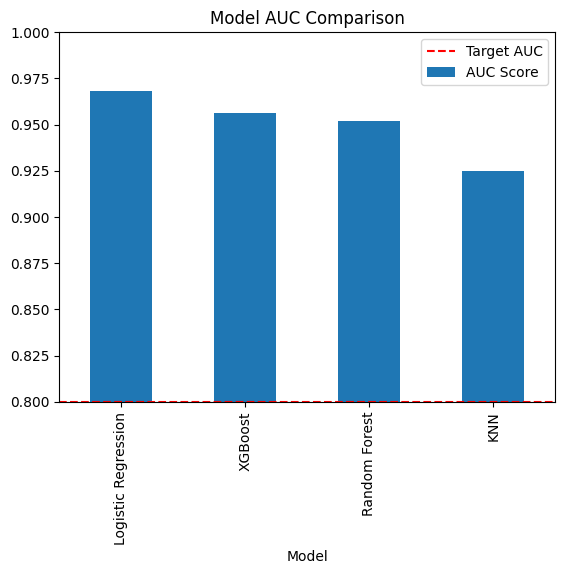

In [42]:
results_df.set_index('Model')['AUC Score'].plot(
    kind='bar',
    ylim=(0.8, 1),
    title='Model AUC Comparison'
)
plt.axhline(0.80, color='red', linestyle='--', label='Target AUC')
plt.legend()
plt.show()


In [51]:
import joblib

best_model_name = results_df.iloc[1]['Model']
best_pipeline = pipelines[best_model_name]

joblib.dump(best_pipeline, r"D:/Blinkit_final_project/delivery_delay_model.pkl")

print(f"Saved model: {best_model_name}")

Saved model: XGBoost
